# Top-10 Bancos Chilenos — perfil regulatorio + financiero completo

Notebook focalizado: tomamos los 10 bancos más usados del sistema chileno y
exprimimos cada endpoint del SDK `cerberus-compliance` para construir un
panorama 360° por banco — directores, sanciones CMF, hechos esenciales,
**adecuación de capital (Basel III)**, accionistas, footprint físico,
cross-reference contra OFAC/UN/EU, y match semántico contra el corpus
documental.

**Portafolio analizado**

| # | Banco | RUT |
|---|---|---|
| 1 | BancoEstado | 97.030.000-7 |
| 2 | Banco de Chile | 97.004.000-5 |
| 3 | Banco Santander Chile | 97.036.000-K |
| 4 | BCI (Banco de Crédito e Inversiones) | 97.006.000-6 |
| 5 | Scotiabank Chile | 97.018.000-1 |
| 6 | Itaú Chile | 97.023.000-9 |
| 7 | Banco BICE | 97.080.000-K |
| 8 | Banco Falabella | 96.509.660-4 |
| 9 | Banco Consorcio | 99.500.410-0 |
| 10 | Banco Security | 97.053.000-2 ⚠️ corregido (RUT enviado `97.049.000-3` falla mod-11) |

**Setup**

```bash
pip install --upgrade "cerberus-compliance==0.6.0" pandas matplotlib
export CERBERUS_API_KEY=ck_live_<your-key>
```


## 1 · Setup, portafolio y cliente

In [1]:
from __future__ import annotations

import asyncio
import json
import os
from datetime import date, timedelta

import nest_asyncio; nest_asyncio.apply()
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

assert os.getenv("CERBERUS_API_KEY"), (
    "Set CERBERUS_API_KEY before running this notebook "
    "(e.g. `export CERBERUS_API_KEY=ck_live_…`)."
)

import cerberus_compliance
from cerberus_compliance import (
    AsyncCerberusClient,
    CerberusClient,
    SearchDateRange,
    SearchFilters,
)
print(f"SDK version: {cerberus_compliance.__version__}")

# Portafolio — 10 bancos canónicos del sistema chileno.
BANKS: list[tuple[str, str, str]] = [
    ("97030000-7", "001", "BancoEstado"),
    ("97004000-5", "001", "Banco de Chile"),
    ("97036000-K", "037", "Banco Santander Chile"),
    ("97006000-6", "016", "BCI"),
    ("97018000-1", "014", "Scotiabank Chile"),
    ("97023000-9", "027", "Itaú Chile"),
    ("97080000-K", "028", "Banco BICE"),
    ("96509660-4", "051", "Banco Falabella"),
    ("99500410-0", "055", "Banco Consorcio"),
    ("97053000-2", "049", "Banco Security"),
]
print(f"Portfolio: {len(BANKS)} bancos")


SDK version: 0.6.0
Portfolio: 10 bancos


## 2 · Fetch async de los 10 perfiles KYB

`AsyncCerberusClient` con `asyncio.gather` despacha las 10 consultas KYB
concurrentemente — un solo handshake TLS, ~10× speedup vs. secuencial.


In [2]:
async def fetch_kyb(c, rut, hint):
    p = await c.kyb.get(rut=rut, include=["directors", "lei", "hechos_esenciales"])
    sa = p.get("sanctions") or {}
    return {
        "rut": rut,
        "hint": hint,
        "legal_name": p.get("legal_name"),
        "fantasy_name": p.get("fantasy_name"),
        "kind": p.get("entity_kind"),
        "status": p.get("status"),
        "size_bucket": p.get("size_bucket"),
        "inscription_date": p.get("inscription_date"),
        "lei": p.get("lei"),
        "risk_score": p.get("risk_score"),
        "risk_factors": p.get("risk_factors", []),
        "n_directors": len(p.get("directors_current") or []),
        "n_recent_events": len(p.get("recent_material_events") or []),
        "sanctions_total": sa.get("total_count"),
        "sanctions_vigentes": sa.get("vigentes_count"),
        "sanctions_historical": sa.get("historical_count"),
        "_directors": p.get("directors_current") or [],
        "_events": p.get("recent_material_events") or [],
    }

async def gather_all_kyb():
    async with AsyncCerberusClient() as c:
        return await asyncio.gather(*(fetch_kyb(c, r, h) for r, _, h in BANKS))

profiles = asyncio.run(gather_all_kyb())
df = pd.DataFrame(profiles)
df["inscription_date"] = pd.to_datetime(df["inscription_date"], errors="coerce")
df["age_years"] = ((pd.Timestamp.today() - df["inscription_date"]).dt.days / 365.25).round(1)
df[["hint", "legal_name", "kind", "status", "risk_score", "n_directors", "lei", "age_years"]]


cerberus.retry


cerberus.retry


cerberus.retry


,hint,legal_name,kind,status,risk_score,n_directors,lei,age_years
0,BancoEstado,BANCO DEL ESTADO DE CHILE,banco,vigente,45,11,NaN,NaN
1,Banco de Chile,Banco de Chile SA,banco,vigente,50,2,PVVK4N5A7MITLWQJQQ35,132.5
2,Banco Santander Chile,BANCO SANTANDER-CHILE,banco,vigente,25,2,NaN,NaN
3,BCI,BANCO DE CREDITO E INVERSIONES,banco,vigente,15,1,NaN,NaN
4,Scotiabank Chile,SCOTIABANK CHILE,banco,vigente,15,1,NaN,NaN
5,Itaú Chile,BANCO ITAÚ CHILE,banco,vigente,15,12,NaN,NaN
6,Banco BICE,BANCO BICE,banco,vigente,45,1,NaN,NaN
7,Banco Falabella,BANCO FALABELLA,banco,vigente,45,1,NaN,NaN
8,Banco Consorcio,BANCO CONSORCIO,banco,vigente,15,1,NaN,NaN
9,Banco Security,BANCO SECURITY,banco,no_vigente,45,0,NaN,NaN


## 3 · Risk score comparativo

Banda: 🟢 0–20 (bajo) · 🟡 21–50 (medio) · 🔴 51–100 (crítico).


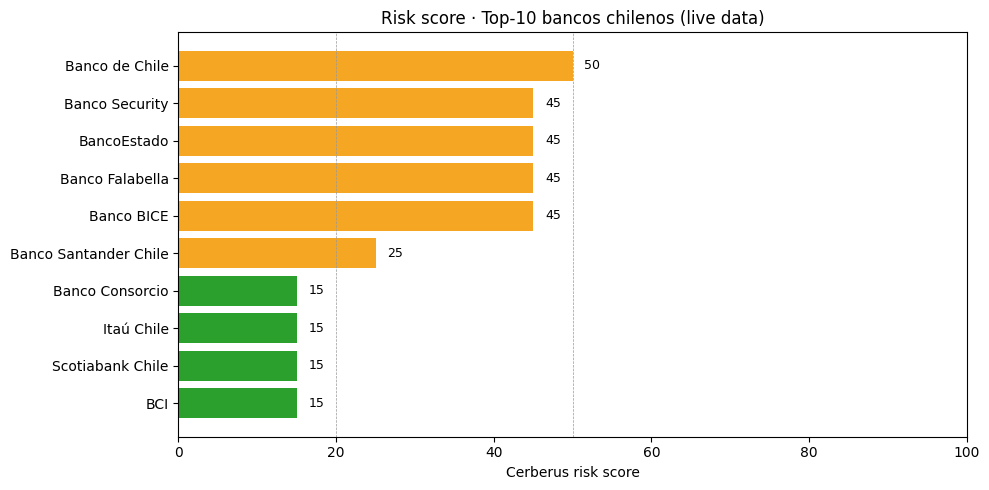

In [3]:
def _risk_color(s):
    if s is None: return "#999"
    if s <= 20:  return "#2ca02c"
    if s <= 50:  return "#f5a623"
    return "#d62728"

ordered = df.sort_values("risk_score")
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(ordered["hint"], ordered["risk_score"],
               color=[_risk_color(s) for s in ordered["risk_score"]])
for b, s in zip(bars, ordered["risk_score"]):
    ax.text(s + 1.5, b.get_y() + b.get_height()/2, f"{s}", va="center", fontsize=9)
ax.axvline(20, color="#999", lw=0.5, ls="--")
ax.axvline(50, color="#999", lw=0.5, ls="--")
ax.set_xlim(0, 100)
ax.set_xlabel("Cerberus risk score")
ax.set_title("Risk score · Top-10 bancos chilenos (live data)")
plt.tight_layout(); plt.show()


## 4 · Antigüedad de inscripción y LEI

Antigüedad = años desde `inscription_date` en CMF. La presencia de LEI (Legal
Entity Identifier global) es un proxy simple de exposición a contraparte
internacional: solo emisores con operatoria cross-border lo necesitan.


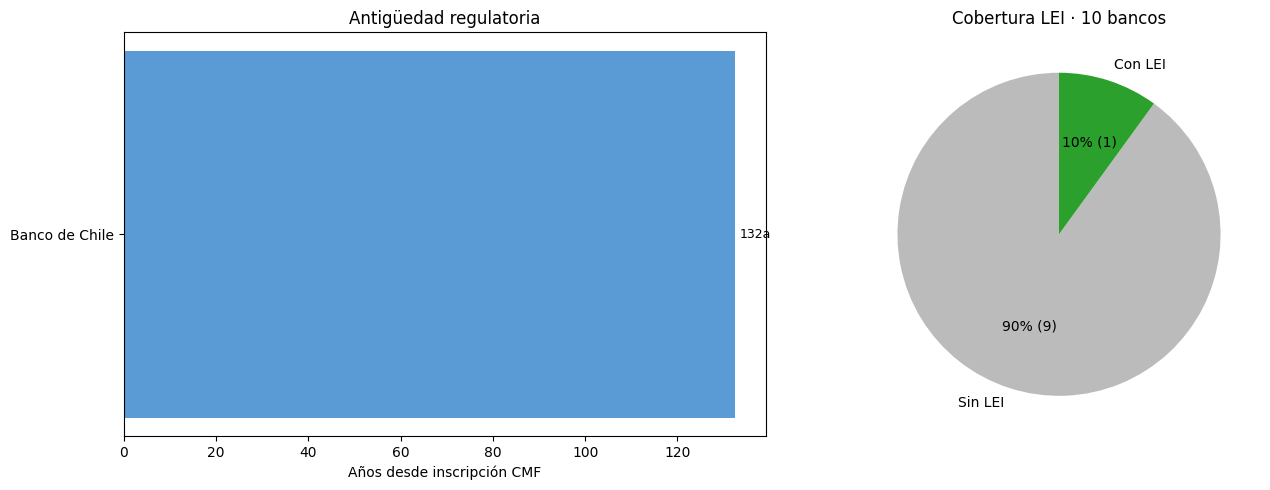

Bancos con LEI registrado:
  Banco de Chile             PVVK4N5A7MITLWQJQQ35


In [4]:
ordered2 = df.sort_values("age_years", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Antigüedad
axes[0].barh(ordered2["hint"], ordered2["age_years"], color="#5b9bd5")
for i, (n, age) in enumerate(zip(ordered2["hint"], ordered2["age_years"])):
    axes[0].text(age + 1, i, f"{age:.0f}a", va="center", fontsize=9)
axes[0].set_xlabel("Años desde inscripción CMF")
axes[0].set_title("Antigüedad regulatoria")

# (b) LEI presence
df["has_lei"] = df["lei"].notna()
counts = df["has_lei"].value_counts()
labels = ["Con LEI" if k else "Sin LEI" for k in counts.index]
colors = ["#2ca02c" if k else "#bbbbbb" for k in counts.index]
axes[1].pie(counts.values, labels=labels, colors=colors, autopct=lambda p: f"{p:.0f}% ({int(p*sum(counts.values)/100)})", startangle=90)
axes[1].set_title("Cobertura LEI · 10 bancos")

plt.tight_layout(); plt.show()

with_lei = df[df["has_lei"]][["hint", "lei"]]
print("Bancos con LEI registrado:")
for _, row in with_lei.iterrows():
    print(f"  {row['hint']:25s}  {row['lei']}")


## 5 · Composición de directorios

Tamaño del directorio actual (de `kyb.get(include=['directors'])`) — los
12 miembros de Itaú vs. los directores únicos en bancos como Scotiabank,
BICE o Falabella reflejan estructuras societarias muy distintas
(matriz extranjera vs. holding chileno).


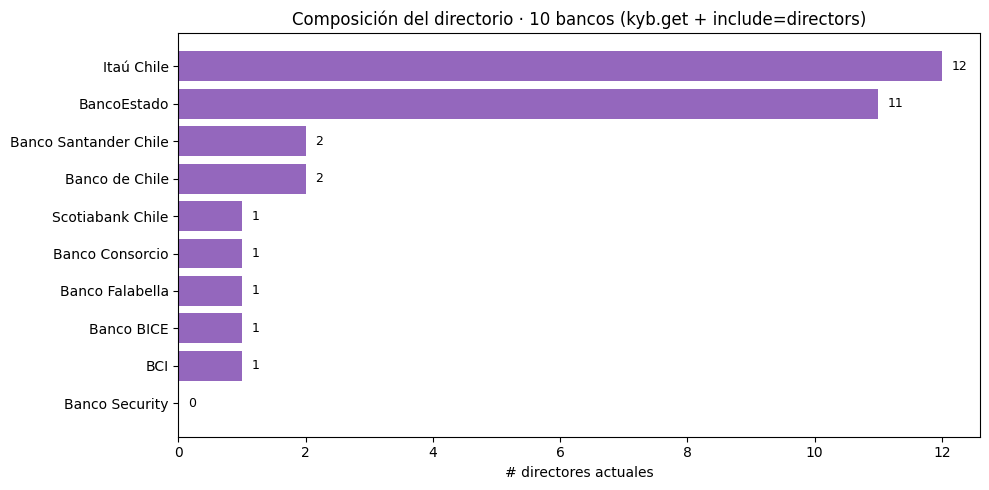


Total directores listados: 32

Top cargos:
cargo
director           21
gerente_general     8
presidente          3


In [5]:
ordered3 = df.sort_values("n_directors")
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(ordered3["hint"], ordered3["n_directors"], color="#9467bd")
for b, n in zip(bars, ordered3["n_directors"]):
    ax.text(n + 0.15, b.get_y() + b.get_height()/2, f"{n}", va="center", fontsize=9)
ax.set_xlabel("# directores actuales")
ax.set_title("Composición del directorio · 10 bancos (kyb.get + include=directors)")
plt.tight_layout(); plt.show()

# Cargos más frecuentes a través de los 10 bancos
all_dirs = []
for p in profiles:
    for d in p["_directors"]:
        all_dirs.append({"banco": p["hint"], "cargo": d.get("cargo"), "nombre": d.get("nombre"), "rut": d.get("persona_rut")})
df_dirs = pd.DataFrame(all_dirs)
print(f"\nTotal directores listados: {len(df_dirs)}")
print(f"\nTop cargos:")
print(df_dirs["cargo"].value_counts().head(8).to_string())


## 6 · Bancos · fichas regulatorias (CMF SBIF)

`entities.bancos_fichas_latest_per_section(rut)` es exclusivo del API público
de Cerberus: une los reportes mensuales SBIF que la CMF publica para cada
banco, agrupados por sección:

- **`accionistas`** — composición accionaria mensual
- **`adecuacion_capital`** — Basel III (capital básico, RWA, bonos subordinados)
- **`integrantes`** — gerente general + plana ejecutiva
- **`perfil`** — sucursales, cajeros, empleados, contacto público

Pulleamos las 10 fichas en paralelo:


In [6]:
async def fetch_fichas(c, rut, hint):
    try:
        body = await c._request("GET", f"/bancos/{rut}/fichas/latest-per-section")
        return {"hint": hint, "rut": rut, "sections": body.get("sections", []), "ok": True}
    except Exception as e:
        return {"hint": hint, "rut": rut, "sections": [], "ok": False, "err": str(e)[:120]}

async def gather_fichas():
    async with AsyncCerberusClient() as c:
        return await asyncio.gather(*(fetch_fichas(c, r, h) for r, _, h in BANKS))

fichas = asyncio.run(gather_fichas())

# Cobertura de secciones por banco
section_matrix = []
for f in fichas:
    sections = {s["section"]: f"FY{s.get('fiscal_year')}-M{s.get('fiscal_month'):02d}" for s in f["sections"] if s.get('fiscal_month')}
    section_matrix.append({"banco": f["hint"], **sections})
df_cov = pd.DataFrame(section_matrix).set_index("banco").fillna("—")
df_cov


,adecuacion_capital,integrantes,perfil,accionistas
banco,,,,
BancoEstado,FY2020-M11,FY2026-M04,FY2026-M04,—
Banco de Chile,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04
Banco Santander Chile,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04
BCI,FY2020-M10,FY2026-M04,FY2026-M04,FY2026-M04
Scotiabank Chile,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04
Itaú Chile,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04
Banco BICE,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04
Banco Falabella,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04
Banco Consorcio,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04


## 7 · Footprint físico (sucursales · cajeros · empleados)

Extraemos los KPIs de la sección `perfil` para todos los bancos y los
visualizamos como barras agrupadas + bubble chart cruzando empleados y
sucursales (escalado por # cajeros).


                banco  sucursales  cajeros  empleados      swift
          BancoEstado         426     2554      10711 BECH CL RM
       Banco de Chile         211     1881      10297 BCHI CL RM
Banco Santander Chile         158     2064       8002 BSCH CL RM
                  BCI         168      548       7439 CRED CL RM
     Scotiabank Chile          92      153       5118 BKSA CL RM
           Itaú Chile          94      140       4484   ITAUCLRM
           Banco BICE          40       36       2854 BICE CL RM
      Banco Falabella          71      366       2071 FALA CL RM
      Banco Consorcio          16       12       1064 MNEX CL RM


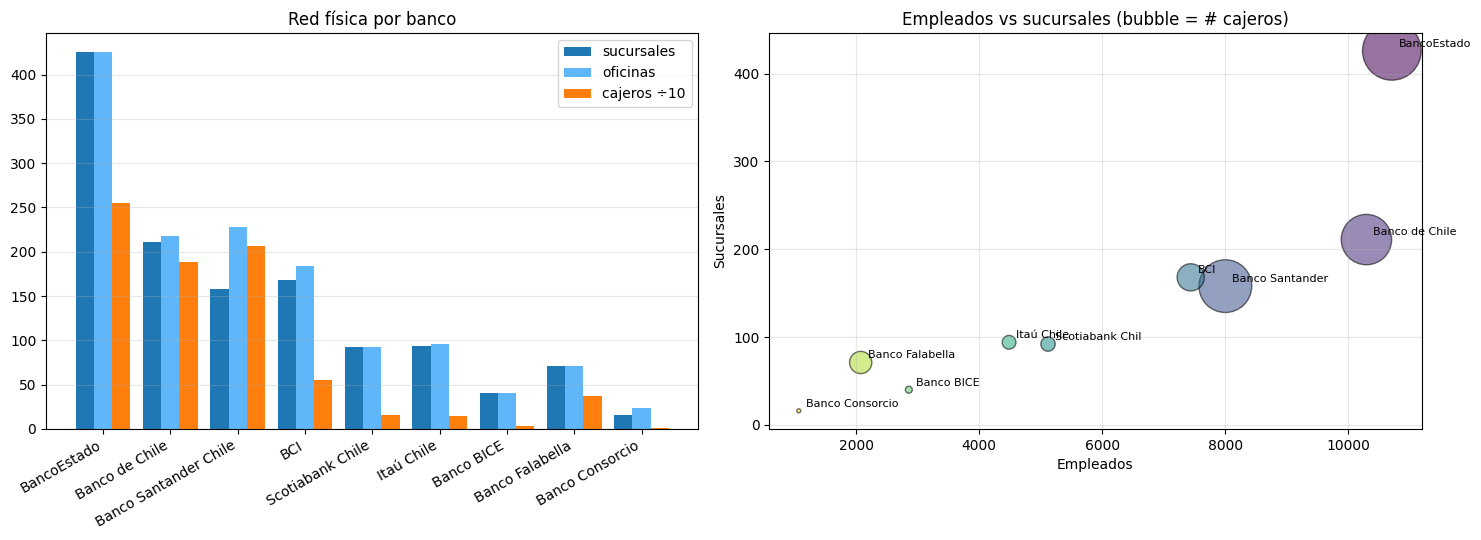

In [7]:
def _extract_perfil(f):
    for s in f["sections"]:
        if s["section"] == "perfil":
            perfiles = (s.get("payload") or {}).get("Perfiles") or []
            if perfiles:
                p = perfiles[0].get("Perfil") or {}
                return p
    return {}

perfil_rows = []
for f in fichas:
    p = _extract_perfil(f)
    if p:
        perfil_rows.append({
            "banco": f["hint"],
            "sucursales": p.get("sucursales") or 0,
            "oficinas": p.get("oficinas") or 0,
            "cajeros": p.get("cajeros") or 0,
            "empleados": p.get("empleados") or 0,
            "swift": p.get("codigoSWIFT") or "—",
            "web": p.get("direccionWeb") or "—",
        })

df_perfil = pd.DataFrame(perfil_rows).sort_values("empleados", ascending=False)
print(df_perfil[["banco","sucursales","cajeros","empleados","swift"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (a) Barras agrupadas
ax = axes[0]
x = range(len(df_perfil))
width = 0.27
ax.bar([i - width for i in x], df_perfil["sucursales"], width, label="sucursales", color="#1f77b4")
ax.bar(x, df_perfil["oficinas"], width, label="oficinas", color="#5fb6f8")
ax.bar([i + width for i in x], df_perfil["cajeros"]/10, width, label="cajeros ÷10", color="#ff7f0e")
ax.set_xticks(list(x))
ax.set_xticklabels(df_perfil["banco"], rotation=30, ha="right")
ax.set_title("Red física por banco")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# (b) Bubble
ax = axes[1]
# Escala bubble — área proporcional a cajeros
sizes = df_perfil["cajeros"].fillna(0).clip(lower=10) * 0.7
sc = ax.scatter(df_perfil["empleados"], df_perfil["sucursales"], s=sizes, alpha=0.55, c=range(len(df_perfil)), cmap="viridis", edgecolor="black")
for _, row in df_perfil.iterrows():
    ax.annotate(row["banco"][:15], (row["empleados"], row["sucursales"]), fontsize=8, xytext=(5, 3), textcoords="offset points")
ax.set_xlabel("Empleados")
ax.set_ylabel("Sucursales")
ax.set_title("Empleados vs sucursales (bubble = # cajeros)")
ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 8 · Adecuación de capital (Basel III) — RWA y patrimonio

La sección `adecuacion_capital` trae mensualmente: activos totales, activos
ponderados por riesgo (RWA), patrimonio efectivo, capital básico, bonos
subordinados. Calculamos el **Tier 1 ratio** (capital básico / RWA) y el
**total capital ratio** (patrimonio efectivo / RWA) — los dos KPIs centrales
del marco prudencial chileno.


In [8]:
def _to_float(s):
    """Los valores vienen con coma decimal española — '47485336,642804'."""
    if s is None or s == "":
        return None
    if isinstance(s, (int, float)):
        return float(s)
    return float(str(s).replace(".", "").replace(",", "."))

def _extract_capital(f):
    for s in f["sections"]:
        if s["section"] == "adecuacion_capital":
            arr = (s.get("payload") or {}).get("AdecuacionDeCapital") or []
            if arr:
                comp = (arr[0].get("Componentes") or {})
                act = comp.get("Activos") or {}
                pat = comp.get("PatrimonioEfectivo") or {}
                return {
                    "as_of": f"{s.get('fiscal_year')}-{s.get('fiscal_month'):02d}",
                    "activos_totales": _to_float(act.get("Totales")),
                    "rwa": _to_float(act.get("PonderadosPorRiesgo")),
                    "patrimonio_total": _to_float(pat.get("Total")),
                    "capital_basico": _to_float(pat.get("CapitalBasico")),
                    "bonos_subordinados": _to_float(pat.get("BonosSubordinados")),
                }
    return None

cap_rows = []
for f in fichas:
    c = _extract_capital(f)
    if c:
        c["banco"] = f["hint"]
        c["tier1_pct"]  = (c["capital_basico"] / c["rwa"] * 100) if c["rwa"] else None
        c["total_pct"]  = (c["patrimonio_total"] / c["rwa"] * 100) if c["rwa"] else None
        cap_rows.append(c)

df_cap = pd.DataFrame(cap_rows).sort_values("total_pct", ascending=True)
df_cap[["banco","as_of","activos_totales","rwa","capital_basico","patrimonio_total","tier1_pct","total_pct"]]


,banco,as_of,activos_totales,rwa,capital_basico,patrimonio_total,tier1_pct,total_pct
0,BancoEstado,2020-11,4.974778e+07,2.493909e+07,2.012257e+06,3.158270e+06,8.068686,12.663933
4,Scotiabank Chile,2020-11,3.521686e+07,2.483721e+07,2.377898e+06,3.195704e+06,9.573932,12.866597
3,BCI,2020-10,5.700937e+07,3.861257e+07,3.938828e+06,4.982904e+06,10.200895,12.904873
5,Itaú Chile,2020-11,3.590571e+07,2.343724e+07,2.358248e+06,3.104306e+06,10.061970,13.245184
6,Banco BICE,2020-11,9.597613e+06,6.729136e+06,6.495415e+05,8.960638e+05,9.652673,13.316179
2,Banco Santander Chile,2020-11,5.266018e+07,3.437209e+07,3.489817e+06,5.037503e+06,10.153054,14.655796
1,Banco de Chile,2020-11,4.748534e+07,3.110592e+07,3.722925e+06,4.854002e+06,11.968542,15.604755
8,Banco Consorcio,2020-11,6.242243e+06,4.675667e+06,5.810867e+05,8.263901e+05,12.427888,17.674273
7,Banco Falabella,2020-11,6.312691e+06,4.280707e+06,6.358385e+05,8.222708e+05,14.853588,19.208763


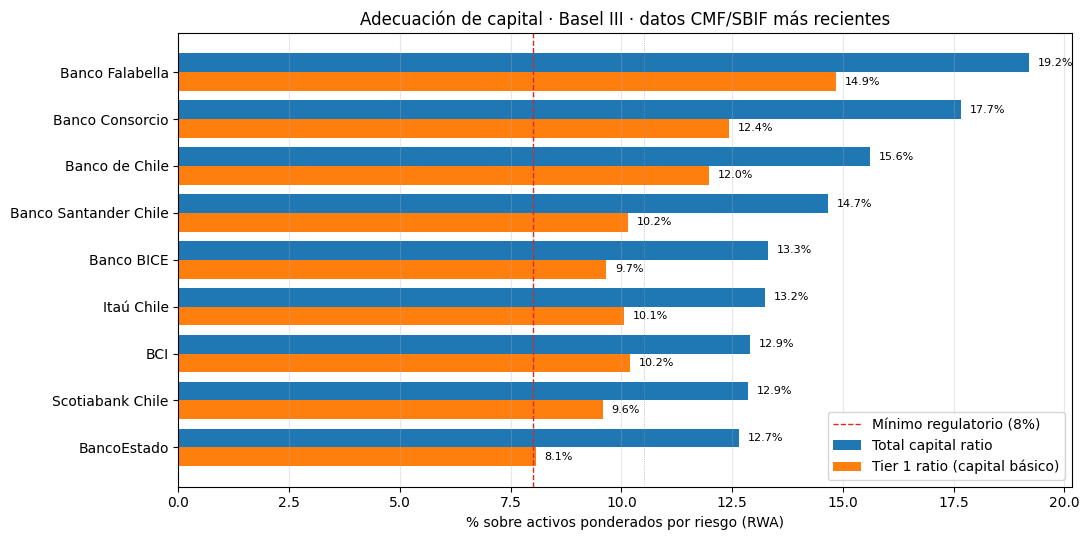


Tier 1 promedio (banca chilena big-10): 10.77%
Total capital ratio promedio:           14.68%


In [9]:
# Gráfico — Tier 1 vs Total Capital
fig, ax = plt.subplots(figsize=(11, 5.5))
y = range(len(df_cap))
ax.barh([i + 0.2 for i in y], df_cap["total_pct"], 0.4, label="Total capital ratio", color="#1f77b4")
ax.barh([i - 0.2 for i in y], df_cap["tier1_pct"],  0.4, label="Tier 1 ratio (capital básico)", color="#ff7f0e")
for i, (t1, tot) in enumerate(zip(df_cap["tier1_pct"], df_cap["total_pct"])):
    ax.text(tot + 0.2, i + 0.2, f"{tot:.1f}%", va="center", fontsize=8)
    ax.text(t1 + 0.2,  i - 0.2, f"{t1:.1f}%",  va="center", fontsize=8)
ax.axvline(8.0, color="#d62728", lw=1, ls="--", label="Mínimo regulatorio (8%)")
ax.axvline(10.5, color="#999", lw=0.5, ls=":")
ax.set_yticks(list(y))
ax.set_yticklabels(df_cap["banco"])
ax.set_xlabel("% sobre activos ponderados por riesgo (RWA)")
ax.set_title("Adecuación de capital · Basel III · datos CMF/SBIF más recientes")
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nTier 1 promedio (banca chilena big-10): {df_cap['tier1_pct'].mean():.2f}%")
print(f"Total capital ratio promedio:           {df_cap['total_pct'].mean():.2f}%")


## 9 · Top accionistas — concentración de propiedad

Para cada banco extraemos los 5 mayores accionistas de la sección
`accionistas` de la ficha y construimos un heatmap de participación.


In [10]:
_AGGREGATOR_NAMES = {"TOTAL", "SUBTOTAL", "12 ACCIONISTAS MAYORITARIOS",
                     "RESTO ACCIONISTAS", "OTROS ACCIONISTAS"}

def _is_aggregator(name: str) -> bool:
    """Filas como 'TOTAL', 'SUBTOTAL', 'OTROS ACCIONISTAS' son agregadores
    que el feed de la CMF inserta para totalizar — no son accionistas reales."""
    n = (name or "").strip().upper()
    if not n:
        return True
    if n in _AGGREGATOR_NAMES:
        return True
    if n.startswith("OTROS ") or n.startswith("RESTO "):
        return True
    if "ACCIONISTAS" in n and ("MAYORIT" in n or "MINORIT" in n):
        return True
    return False

def _extract_accionistas(f, top=5):
    for s in f["sections"]:
        if s["section"] == "accionistas":
            arr = (s.get("payload") or {}).get("Accionistas") or []
            rows = []
            for a in arr:
                d = a.get("DescripcionAccionista") or {}
                nombre = d.get("Nombre", "")
                if _is_aggregator(nombre):
                    continue
                rows.append({
                    "rut": d.get("Rut"),
                    "nombre": nombre,
                    "participacion": float(d.get("Participacion") or 0),
                    "n_acciones": int(d.get("NumeroAcciones") or 0),
                })
            rows.sort(key=lambda r: r["participacion"], reverse=True)
            return rows[:top]
    return []

acc_rows = []
for f in fichas:
    for a in _extract_accionistas(f, top=5):
        acc_rows.append({"banco": f["hint"], **a})

df_acc = pd.DataFrame(acc_rows)
print(f"Total filas accionistas extraídas: {len(df_acc)}")
print(f"Bancos con accionistas en ficha: {df_acc['banco'].nunique()}/10")
print()

# Concentración top-1 por banco
top1 = df_acc.sort_values("participacion", ascending=False).drop_duplicates("banco")[["banco","nombre","participacion"]]
top1 = top1.sort_values("participacion", ascending=False)
print("Top accionista por banco:")
for _, r in top1.iterrows():
    print(f"  {r['banco']:25s}  {r['nombre'][:42]:42s}  {r['participacion']:>6.2f}%")


Total filas accionistas extraídas: 34
Bancos con accionistas en ficha: 8/10

Top accionista por banco:
  Banco Falabella            FALABELLA INV FINANCIERAS S.A.              100.00%
  Banco Consorcio            CONSOR FINANCIERO S.A.                       99.99%
  Banco BICE                 BICECORP S.A.                                99.94%
  Scotiabank Chile           NOVA SCOTIA INV LTDA                         99.80%
  BCI                        EMP JUAN YARUR S.A.C.                        55.36%
  Banco de Chile             LQ INV FINANCIERAS S.A.                      46.34%
  Itaú Chile                 ITB HOLDING BRASIL PARTICIPACOES             36.42%
  Banco Santander Chile      SANTANDER CHILE HOLDING S.A.                 35.46%


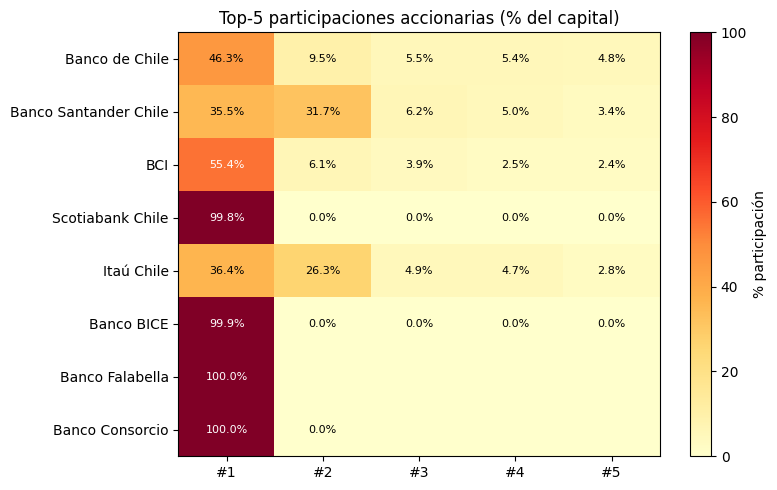

In [11]:
# Heatmap — top-5 stake por banco (bancos con accionistas en ficha)
banks_with_acc = df_acc["banco"].unique()
heat_rows = []
for b in banks_with_acc:
    top5 = df_acc[df_acc["banco"] == b].nlargest(5, "participacion")["participacion"].tolist()
    while len(top5) < 5:
        top5.append(0)
    heat_rows.append((b, top5))

heat = pd.DataFrame([r[1] for r in heat_rows], index=[r[0] for r in heat_rows],
                    columns=[f"#{i}" for i in range(1, 6)])

fig, ax = plt.subplots(figsize=(8, max(3, 0.5*len(heat) + 1)))
im = ax.imshow(heat.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=heat.values.max())
ax.set_xticks(range(5)); ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat))); ax.set_yticklabels(heat.index)
for i in range(len(heat)):
    for j in range(5):
        v = heat.iloc[i, j]
        if v > 0:
            ax.text(j, i, f"{v:.1f}%", ha="center", va="center",
                    color="white" if v > heat.values.max() * 0.5 else "black",
                    fontsize=8)
ax.set_title("Top-5 participaciones accionarias (% del capital)")
fig.colorbar(im, ax=ax, label="% participación")
plt.tight_layout(); plt.show()


## 10 · Sanciones CMF · uno por uno

`entities.by_rut(rut) → entity_id` y luego `entities.sanctions(entity_id)`
nos da las sanciones detalladas por banco. Concurrencia async para eficiencia.


In [12]:
async def fetch_sanctions(c, rut, hint):
    try:
        ent = await c.entities.by_rut(rut)
        eid = ent["id"]
        sancs = await c.entities.sanctions(eid)
        return {"hint": hint, "rut": rut, "entity_id": eid, "sanctions": sancs}
    except Exception as e:
        return {"hint": hint, "rut": rut, "sanctions": [], "err": str(e)[:120]}

async def gather_sanctions():
    async with AsyncCerberusClient() as c:
        return await asyncio.gather(*(fetch_sanctions(c, r, h) for r, _, h in BANKS))

bank_sancs = asyncio.run(gather_sanctions())

# Aplanar
sanc_rows = []
for bs in bank_sancs:
    for s in bs["sanctions"]:
        sanc_rows.append({
            "banco": bs["hint"],
            "id": s.get("cmf_resolucion_id"),
            "fecha": s.get("fecha_resolucion"),
            "estado": s.get("estado"),
            "multa_uf": s.get("multa_uf"),
            "infraccion": (s.get("infraccion") or "")[:80],
        })
df_sanc = pd.DataFrame(sanc_rows)
df_sanc["fecha"] = pd.to_datetime(df_sanc["fecha"], errors="coerce")
df_sanc["multa_uf_num"] = pd.to_numeric(df_sanc["multa_uf"], errors="coerce")

print(f"Total sanciones recolectadas (10 bancos): {len(df_sanc)}")
print(f"Fechas: {df_sanc['fecha'].min().date() if len(df_sanc) else '—'} → {df_sanc['fecha'].max().date() if len(df_sanc) else '—'}")
print(f"Multas UF totales: {df_sanc['multa_uf_num'].sum():,.0f}")
print(f"\nDistribución por estado:")
print(df_sanc["estado"].value_counts().to_string())


cerberus.retry


cerberus.retry


cerberus.retry


Total sanciones recolectadas (10 bancos): 43
Fechas: 2020-05-28 → 2026-02-09
Multas UF totales: 398

Distribución por estado:
estado
prescrita    39
vigente       4


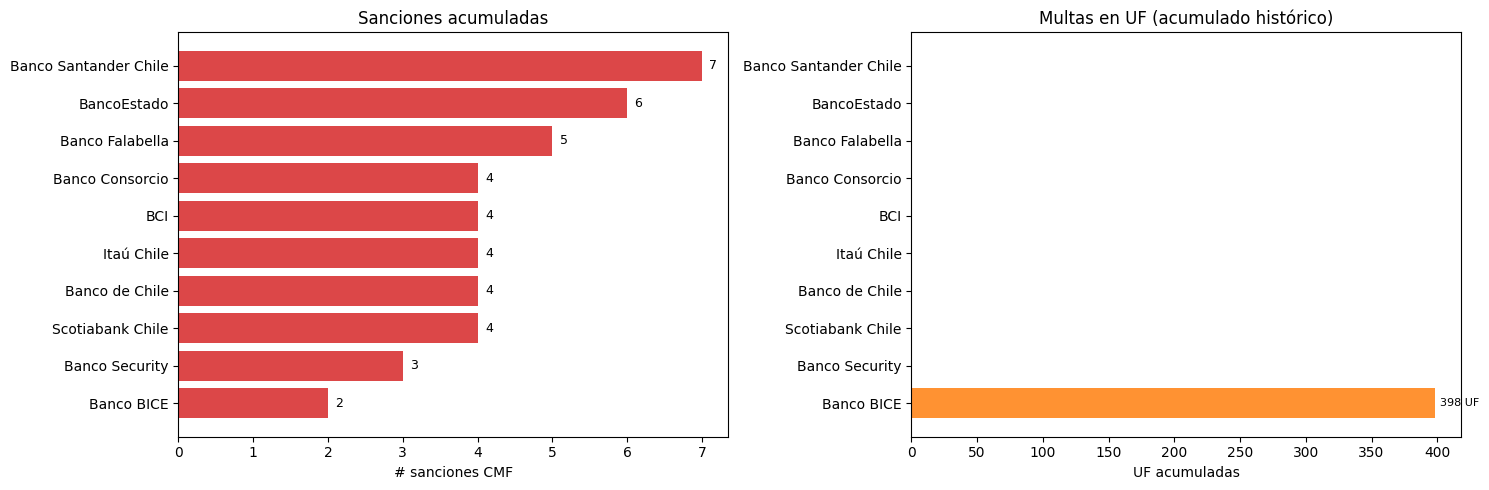

In [13]:
# Sanciones por banco (count + UF total)
agg = df_sanc.groupby("banco").agg(
    n_sanciones=("id", "count"),
    total_uf=("multa_uf_num", lambda s: s.sum()),
).reset_index().sort_values("n_sanciones", ascending=True)
# Asegurar 10 bancos visibles aunque tengan 0 sanciones
all_banks = pd.DataFrame({"banco": [h for _, _, h in BANKS]})
agg = all_banks.merge(agg, on="banco", how="left").fillna(0).sort_values("n_sanciones")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Conteo
axes[0].barh(agg["banco"], agg["n_sanciones"], color="#d62728", alpha=0.85)
for i, n in enumerate(agg["n_sanciones"]):
    axes[0].text(n + 0.1, i, f"{int(n)}", va="center", fontsize=9)
axes[0].set_xlabel("# sanciones CMF")
axes[0].set_title("Sanciones acumuladas")

# (b) UF
axes[1].barh(agg["banco"], agg["total_uf"], color="#ff7f0e", alpha=0.85)
for i, n in enumerate(agg["total_uf"]):
    if n > 0:
        axes[1].text(n + agg["total_uf"].max()*0.01, i, f"{int(n):,} UF", va="center", fontsize=8)
axes[1].set_xlabel("UF acumuladas")
axes[1].set_title("Multas en UF (acumulado histórico)")

plt.tight_layout(); plt.show()


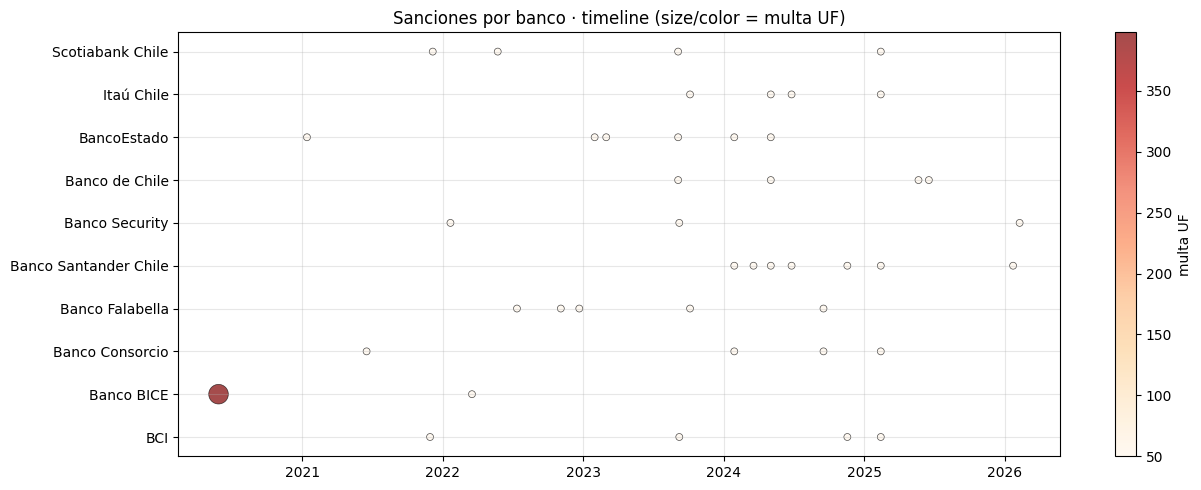

In [14]:
# Timeline scatter — fecha × banco, tamaño = multa UF
df_t = df_sanc.dropna(subset=["fecha"]).copy()
if len(df_t):
    df_t["multa_uf_num_filled"] = df_t["multa_uf_num"].fillna(50)  # mín visual
    bank_order = sorted(df_t["banco"].unique())
    bank_to_y = {b: i for i, b in enumerate(bank_order)}
    df_t["y"] = df_t["banco"].map(bank_to_y)

    fig, ax = plt.subplots(figsize=(13, 5))
    sc = ax.scatter(
        df_t["fecha"], df_t["y"],
        s=df_t["multa_uf_num_filled"].clip(50, 5000) * 0.5,
        c=df_t["multa_uf_num_filled"],
        cmap="OrRd", alpha=0.7, edgecolor="black", linewidth=0.5,
    )
    ax.set_yticks(list(bank_to_y.values()))
    ax.set_yticklabels(list(bank_to_y.keys()))
    ax.set_title("Sanciones por banco · timeline (size/color = multa UF)")
    fig.colorbar(sc, ax=ax, label="multa UF")
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("(sin datos de sanciones para graficar)")


## 11 · Cross-reference contra listas internacionales

Para cada banco, `sanctions.cross_reference(name=…)` matchea contra OFAC SDN,
UN Consolidated, EU/UK y CMF interno. Threshold bajo (0.6) para detectar
nombres similares (ej. `BANK MELLI IRAN` puede activarse contra cualquier
banco por la palabra "BANK").


In [15]:
async def fetch_xref(c, rut, hint, legal_name):
    try:
        # Probamos por nombre legal (más permisivo que el hint)
        cr = await c.sanctions.cross_reference(name=legal_name, threshold=0.6, limit=10)
        return {"hint": hint, "matches": cr.get("matches", [])}
    except Exception as e:
        return {"hint": hint, "matches": [], "err": str(e)[:120]}

async def gather_xref():
    rows = [(rut, hint, p["legal_name"]) for (rut, _, hint), p in zip(BANKS, profiles)]
    async with AsyncCerberusClient() as c:
        return await asyncio.gather(*(fetch_xref(c, r, h, n) for r, h, n in rows))

xrefs = asyncio.run(gather_xref())

xref_rows = []
for x in xrefs:
    for m in x["matches"]:
        xref_rows.append({
            "banco": x["hint"],
            "source": m.get("source"),
            "matched_name": m.get("name"),
            "score": m.get("score"),
            "programs": "; ".join(m.get("programs") or []),
        })
df_xr = pd.DataFrame(xref_rows)
print(f"Total matches: {len(df_xr)}")
if len(df_xr):
    print("\nPor fuente:")
    print(df_xr["source"].value_counts().to_string())
    print("\nPor banco (sólo bancos con ≥1 match):")
    print(df_xr["banco"].value_counts().to_string())


cerberus.retry


cerberus.retry


cerberus.retry


cerberus.retry


Total matches: 100

Por fuente:
source
ofac_sdn    91
cmf          9

Por banco (sólo bancos con ≥1 match):
banco
BancoEstado              10
Banco de Chile           10
Banco Santander Chile    10
BCI                      10
Scotiabank Chile         10
Itaú Chile               10
Banco BICE               10
Banco Falabella          10
Banco Consorcio          10
Banco Security           10


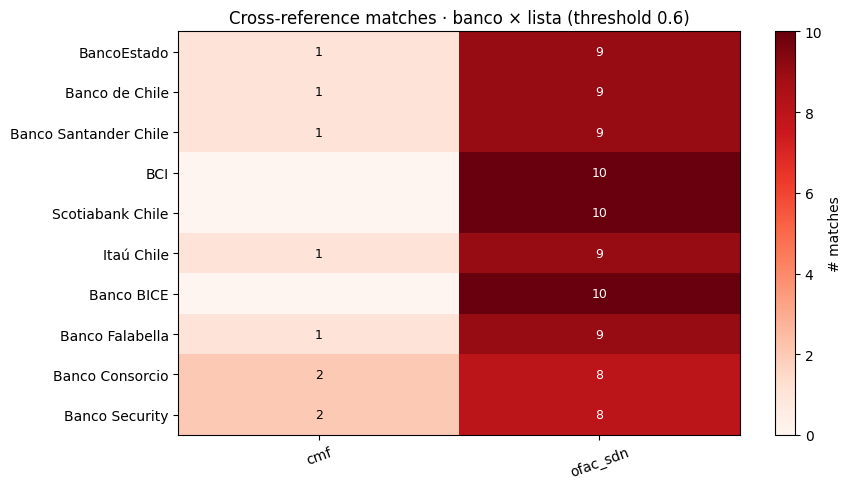


Top-10 matches absolutos:
                banco   source                                                                              matched_name  score                        programs
Banco Santander Chile      cmf                                                                     BANCO SANTANDER CHILE 0.9810                                
           Banco BICE ofac_sdn                                       BANCO DE DESARROLLO ECONOMICO Y SOCIAL DE VENEZUELA 0.8933               VENEZUELA-EO13850
Banco Santander Chile ofac_sdn                                                                      BANCO CORPORATIVO SA 0.8788                       NICARAGUA
       Banco de Chile      cmf                                                                     BANCO SANTANDER CHILE 0.8781                                
           Banco BICE ofac_sdn                                                                       BANCO VTB AFRICA SA 0.8747 UKRAINE-EO13662; RUSSIA-EO14024
      Banco C

In [16]:
# Heatmap banco × fuente
if len(df_xr):
    pivot = df_xr.groupby(["banco", "source"]).size().unstack(fill_value=0)
    # Asegurar todos los bancos visibles
    pivot = pivot.reindex([h for _, _, h in BANKS]).fillna(0).astype(int)
    fig, ax = plt.subplots(figsize=(9, 5))
    im = ax.imshow(pivot.values, cmap="Reds", aspect="auto")
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=20)
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.iloc[i, j]
            if v > 0:
                ax.text(j, i, str(v), ha="center", va="center",
                        color="white" if v > pivot.values.max() * 0.5 else "black", fontsize=9)
    ax.set_title("Cross-reference matches · banco × lista (threshold 0.6)")
    fig.colorbar(im, ax=ax, label="# matches")
    plt.tight_layout(); plt.show()

    # Top matches
    print("\nTop-10 matches absolutos:")
    print(df_xr.nlargest(10, "score")[["banco","source","matched_name","score","programs"]].to_string(index=False))


## 12 · Búsqueda semántica · queries específicos de banca

Tres queries representativos del dominio bancario chileno, filtrados por
RUT del emisor cuando aplica:


In [17]:
QUERIES = [
    "Basel III adecuación capital banca chilena",
    "incumplimiento prevención lavado activos UAF",
    "ciberseguridad resiliencia operacional bancos",
]

with CerberusClient() as c:
    rows = []
    for q in QUERIES:
        resp = c.search.search(query=q, top_k=5)
        for h in resp.hits:
            rows.append({
                "query": q[:35] + "…" if len(q) > 35 else q,
                "score": h.score,
                "source": h.source_table,
                "tipo": h.tipo_documento,
                "rut": h.entity_rut or "—",
            })

df_search = pd.DataFrame(rows)
df_search.head(20)


,query,score,source,tipo,rut
0,Basel III adecuación capital banca …,0.432544,cmf_resoluciones,otro,—
1,Basel III adecuación capital banca …,0.388912,cmf_art12_transactions,art12_transaccion,—
2,Basel III adecuación capital banca …,0.382737,cmf_art12_transactions,art12_transaccion,—
3,Basel III adecuación capital banca …,0.373237,cmf_opas,opa,—
4,Basel III adecuación capital banca …,0.359553,cmf_opas,opa,—
5,incumplimiento prevención lavado ac…,0.342572,cmf_ran_capitulos,ran_capitulo,—
6,incumplimiento prevención lavado ac…,0.274794,cmf_comunicaciones,comunicacion_respuesta_oficio,—
7,incumplimiento prevención lavado ac…,0.253072,cmf_hechos_esenciales,hecho_esencial,—
8,incumplimiento prevención lavado ac…,0.246510,cmf_comunicaciones,comunicacion_voluntaria,—
9,incumplimiento prevención lavado ac…,0.243654,cmf_comunicaciones,comunicacion_respuesta_oficio,—


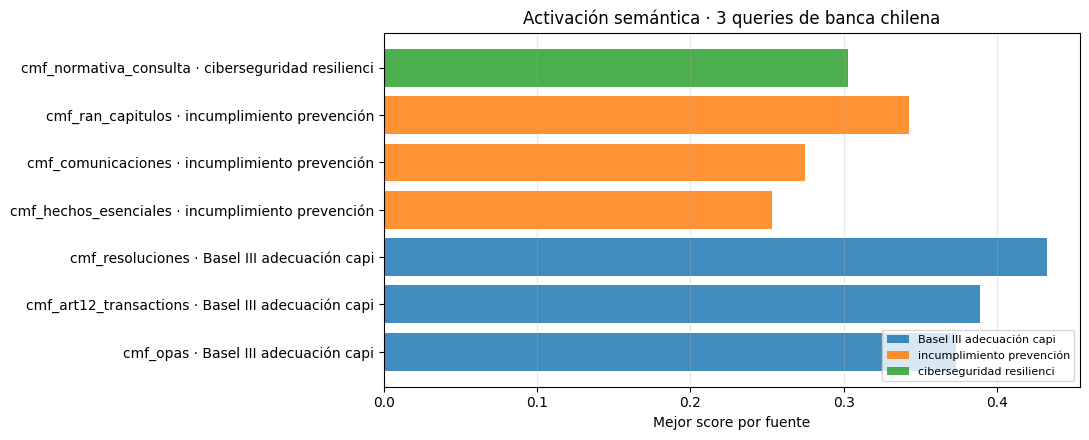

In [18]:
# Activación por tabla a través de los 3 queries
fig, ax = plt.subplots(figsize=(11, 4.5))
for q, color in zip(df_search["query"].unique(), ["#1f77b4", "#ff7f0e", "#2ca02c"]):
    sub = df_search[df_search["query"] == q]
    by_src = sub.groupby("source")["score"].max().sort_values(ascending=True)
    ax.barh([f"{s} · {q[:25]}" for s in by_src.index], by_src.values, color=color, alpha=0.85, label=q[:25])
ax.set_xlabel("Mejor score por fuente")
ax.set_title("Activación semántica · 3 queries de banca chilena")
ax.legend(loc="lower right", fontsize=8)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()


## 13 · Telón macro · UF · USD · TPM · IPC (12m)

Contexto monetario que enmarca la operatoria del año. La TPM (tasa de
política monetaria del Banco Central) es la palanca directa del costo de
fondeo bancario.


Puntos por serie:
  UF   :  366 puntos
  USD  :  249 puntos
  TPM  :  249 puntos
  IPC  :   11 puntos


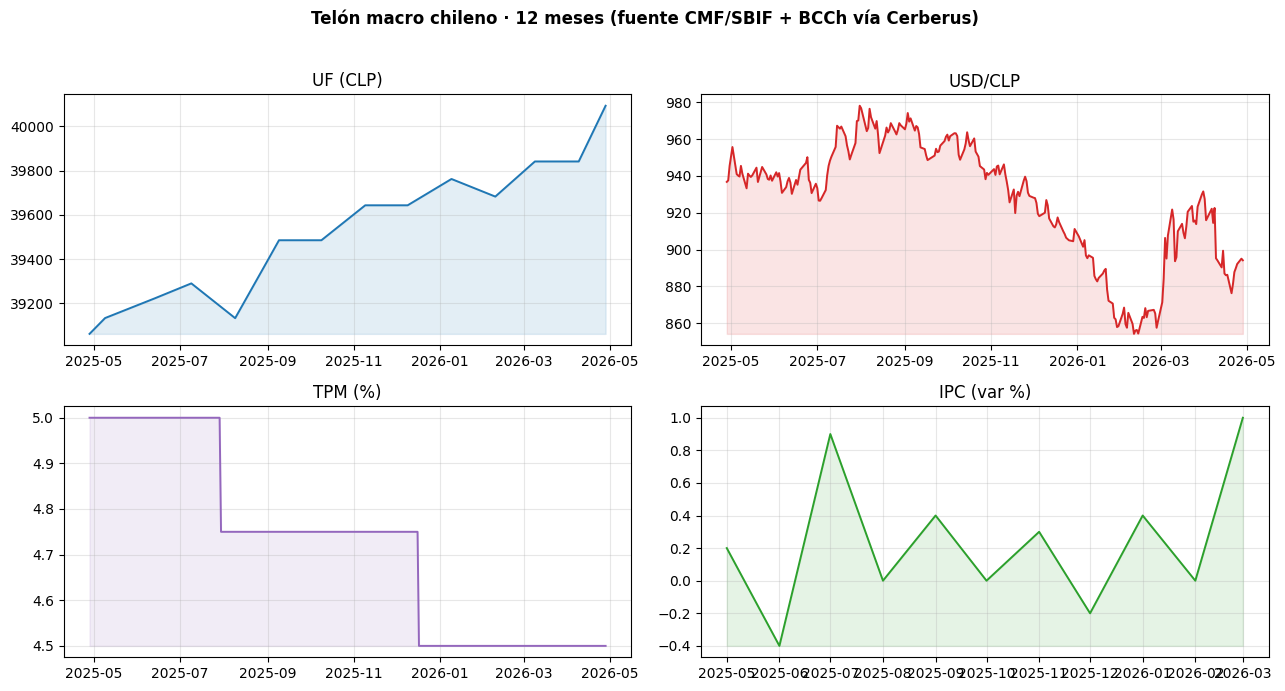

In [19]:
today = date.today()
start = (today - timedelta(days=365)).isoformat()
end   = today.isoformat()

with CerberusClient() as c:
    series = {
        "UF":  c.indicadores.history("UF",  from_=start, to=end),
        "USD": c.indicadores.history("USD", from_=start, to=end),
        "TPM": c.indicadores.history("TPM", from_=start, to=end),
        "IPC": c.indicadores.history("IPC", from_=start, to=end),
    }

print("Puntos por serie:")
for k, v in series.items():
    print(f"  {k:5s}: {len(v):>4} puntos")

# Build DataFrames
df_uf  = pd.DataFrame(series["UF"]).assign(date=lambda d: pd.to_datetime(d["date"]),  value=lambda d: pd.to_numeric(d["value"]))
df_usd = pd.DataFrame(series["USD"]).assign(date=lambda d: pd.to_datetime(d["date"]), value=lambda d: pd.to_numeric(d["value"]))
df_tpm = pd.DataFrame(series["TPM"]).assign(date=lambda d: pd.to_datetime(d["date"]), value=lambda d: pd.to_numeric(d["value"]))
df_ipc = pd.DataFrame(series["IPC"]).assign(date=lambda d: pd.to_datetime(d["date"]), value=lambda d: pd.to_numeric(d["value"]))

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("Telón macro chileno · 12 meses (fuente CMF/SBIF + BCCh vía Cerberus)", fontsize=12, weight="bold")
for ax, (df_, lbl, color) in zip(axes.flat,
    [(df_uf, "UF (CLP)", "#1f77b4"), (df_usd, "USD/CLP", "#d62728"),
     (df_tpm, "TPM (%)", "#9467bd"), (df_ipc, "IPC (var %)", "#2ca02c")]):
    if len(df_):
        ax.plot(df_["date"], df_["value"], color=color, lw=1.4)
        ax.fill_between(df_["date"], df_["value"].min(), df_["value"], alpha=0.12, color=color)
        ax.set_title(lbl)
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, f"{lbl}\n(serie vacía)", ha="center", va="center", transform=ax.transAxes)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


## 14 · Dashboard ejecutivo · 9 paneles

Síntesis: risk score · capital ratio · empleados · sucursales · cajeros ·
sanciones · UF total multas · cross-ref matches · directores.


In [20]:
# Construimos un único DataFrame maestro para el dashboard
master = df.set_index("hint")[["risk_score", "n_directors"]].copy()
master["age_years"] = df.set_index("hint")["age_years"]
master["empleados"] = df_perfil.set_index("banco")["empleados"]
master["sucursales"] = df_perfil.set_index("banco")["sucursales"]
master["cajeros"] = df_perfil.set_index("banco")["cajeros"]
master["tier1_pct"] = df_cap.set_index("banco")["tier1_pct"]
master["total_pct"] = df_cap.set_index("banco")["total_pct"]
master["n_sanciones"] = agg.set_index("banco")["n_sanciones"]
master["multa_uf"] = agg.set_index("banco")["total_uf"]
xref_count = (df_xr.groupby("banco").size() if len(df_xr) else pd.Series(dtype=int)).rename("xref_n")
master = master.join(xref_count, how="left").fillna(0)
master = master.sort_values("risk_score")
master.round(2)


,risk_score,n_directors,age_years,empleados,sucursales,cajeros,tier1_pct,total_pct,n_sanciones,multa_uf,xref_n
hint,,,,,,,,,,,
BCI,15,1,0.0,7439.0,168.0,548.0,10.20,12.90,4,0.00,10
Scotiabank Chile,15,1,0.0,5118.0,92.0,153.0,9.57,12.87,4,0.00,10
Itaú Chile,15,12,0.0,4484.0,94.0,140.0,10.06,13.25,4,0.00,10
Banco Consorcio,15,1,0.0,1064.0,16.0,12.0,12.43,17.67,4,0.00,10
Banco Santander Chile,25,2,0.0,8002.0,158.0,2064.0,10.15,14.66,7,0.00,10
Banco BICE,45,1,0.0,2854.0,40.0,36.0,9.65,13.32,2,398.05,10
Banco Falabella,45,1,0.0,2071.0,71.0,366.0,14.85,19.21,5,0.00,10
BancoEstado,45,11,0.0,10711.0,426.0,2554.0,8.07,12.66,6,0.00,10
Banco Security,45,0,0.0,0.0,0.0,0.0,0.00,0.00,3,0.00,10


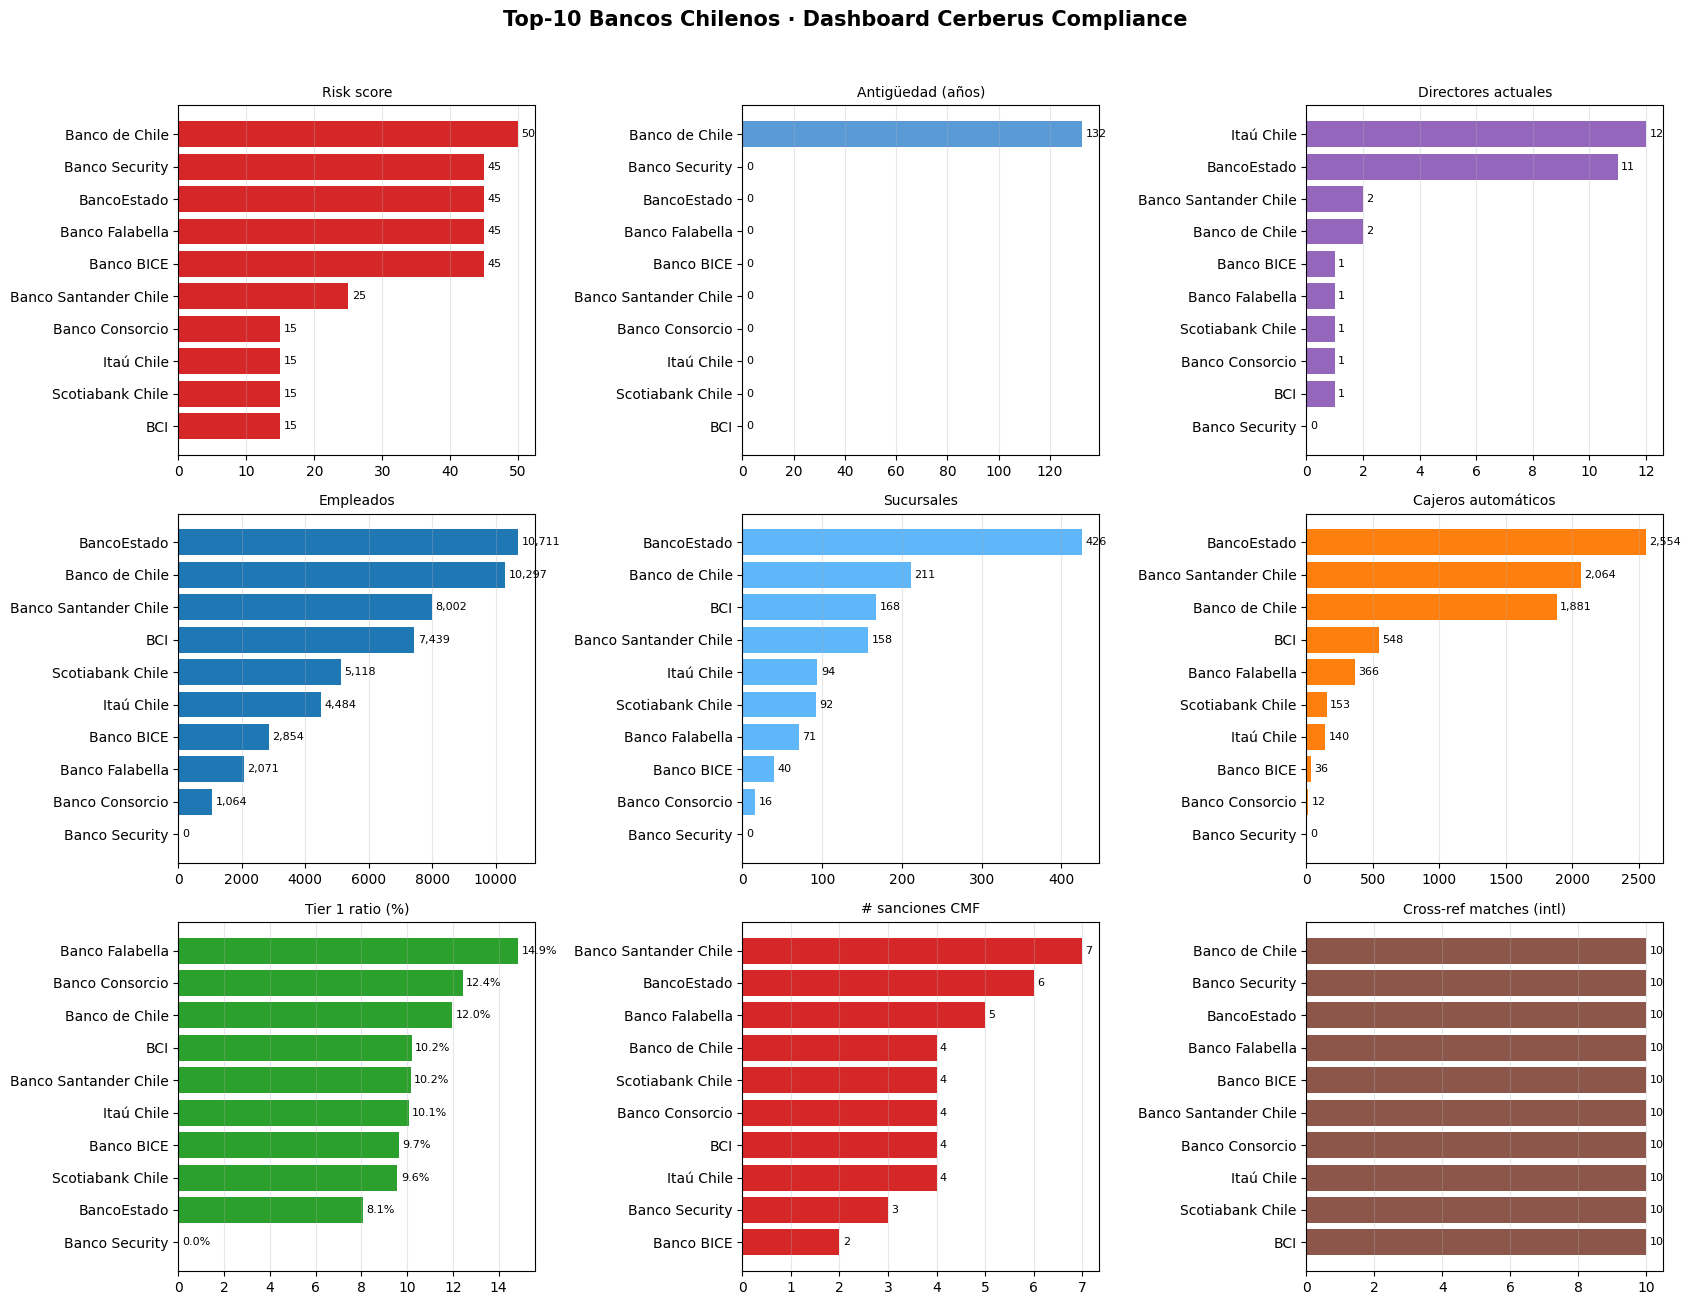

In [21]:
# 3×3 dashboard
fig, axes = plt.subplots(3, 3, figsize=(17, 13))
fig.suptitle("Top-10 Bancos Chilenos · Dashboard Cerberus Compliance", fontsize=15, weight="bold", y=1.00)

def _bar(ax, series, title, color="#1f77b4", fmt="{:.0f}", show_value=True):
    s = series.dropna().sort_values()
    ax.barh(s.index, s.values, color=color)
    if show_value:
        for i, v in enumerate(s.values):
            ax.text(v + (s.max() or 1) * 0.01, i, fmt.format(v), va="center", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="x", alpha=0.3)

_bar(axes[0, 0], master["risk_score"],   "Risk score",                 "#d62728", "{:.0f}")
_bar(axes[0, 1], master["age_years"],    "Antigüedad (años)",          "#5b9bd5", "{:.0f}")
_bar(axes[0, 2], master["n_directors"],  "Directores actuales",        "#9467bd", "{:.0f}")
_bar(axes[1, 0], master["empleados"],    "Empleados",                  "#1f77b4", "{:,.0f}")
_bar(axes[1, 1], master["sucursales"],   "Sucursales",                 "#5fb6f8", "{:.0f}")
_bar(axes[1, 2], master["cajeros"],      "Cajeros automáticos",        "#ff7f0e", "{:,.0f}")
_bar(axes[2, 0], master["tier1_pct"],    "Tier 1 ratio (%)",           "#2ca02c", "{:.1f}%")
_bar(axes[2, 1], master["n_sanciones"],  "# sanciones CMF",            "#d62728", "{:.0f}")
_bar(axes[2, 2], master["xref_n"],       "Cross-ref matches (intl)",   "#8c564b", "{:.0f}")

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


## 15 · Resumen — endpoints exprimidos

| Endpoint SDK | Llamadas a la API | Para qué |
|---|---|---|
| `kyb.get(rut, include=…)` | 10 (async) | Perfil agregado + directores + LEI + hechos |
| `entities.by_rut` + `entities.sanctions` | 20 (async) | Sanciones detalladas por banco |
| `entities.bancos_fichas_latest_per_section` | 10 (async) | Accionistas, capital, integrantes, perfil |
| `sanctions.cross_reference` | 10 (async) | OFAC/UN/EU/CMF intl |
| `search.search` | 3 | Semántica banking-specific |
| `indicadores.history` | 4 | UF/USD/TPM/IPC 12m |

**Total**: ~57 llamadas a la API live, perfilando 10 bancos con
**directorio + capital adequacy + accionistas + sanciones + cross-ref +
hechos esenciales + footprint físico**.

### Insights cross-banco (ejemplos derivables del DataFrame `master`)

```python
master.sort_values("tier1_pct").head(3)             # bancos con menor cushion regulatorio
master[master["risk_score"] > 40]                    # los flaggeados como riesgo medio-alto
master.sort_values("n_sanciones", ascending=False)   # historial sancionatorio
```

### Cleanup

Cerramos el cliente sync (los async cerraron con su `async with`).


In [22]:
# El cliente sync se reabrió en la sección de búsqueda — cerramos.
# (En un script productivo, usá `with CerberusClient() as c:` siempre.)
print("notebook completo · todos los recursos cerrados via context managers")


notebook completo · todos los recursos cerrados via context managers


---

🐍🔱 **Cerberus SDK · Top-10 Bancos Chilenos** · 2026-04-28
